# Pitch Type Classification — Unsupervised Clustering

Builds the pitch-type model the "Guess the Pitch" app pivot depends on: an
unsupervised classifier that assigns every pitch in `pitch_movement.csv`
(release speed + induced vertical break + horizontal break, derived in
`scripts/derive_pitch_movement.py` from the raw ~20Hz ball-tracking
samples) to a pitch-type cluster, with a best-effort canonical name
(Fastball/Slider/Curveball/etc.) attached.

**Why this is harder than a normal pitch classifier:** this dataset has no
ground-truth pitch-type label to train against (unlike MLB Statcast, which
tags `pitch_type` from a vendor's own model), and critically **no pitcher
handedness field anywhere** (checked `lineups.csv`, `game-info.csv`, every
ball-events/ball-positions schema). Real-world pitch classifiers (e.g. the
UCSD Triton Baseball pipeline this approach is adapted from,
`jackkalsched/UCSD_Baseball_25`, `Pitching/pitch classification/
classification_v1.ipynb`) mirror horizontal break by a *known* throwing
hand so a lefty's slider and a righty's slider land in the same region of
break-space. We don't have that label, so this notebook infers an
equivalent "arm-side" reference sign for each pitcher directly from their
own data (Sec. 3) and validates that inference empirically (Sec. 3.1)
instead of trusting a hand-coded field.

**Methodology, decided with the user (2026-06-30):**
1. Compute a data-driven arm-side sign per pitcher from their hardest
   pitches, mirror horizontal break by it (Sec. 3).
2. Standardize (z-score) velocity/IVB/mirrored-HB *within each pitcher*
   (Sec. 4) -- this is what makes pitchers comparable without real
   handedness or stuff-quality normalization: a cluster captures "how
   unusual is this pitch *for this pitcher*," not absolute movement.
3. Pool every pitcher's standardized pitches and fit **one global Gaussian
   Mixture Model**, with BIC search over both `k` (number of pitch types)
   and covariance type (Sec. 5) -- GMM over k-means because real pitch
   clusters are elliptical/correlated (a slider's break magnitude
   correlates with how much it gives up in velocity), not spherical.
4. Validate the fitted model with concrete numeric checks (Sec. 6), the
   same PASS/FAIL `grade()` convention `process_assessment.ipynb` uses for
   the rest of this pipeline.
5. Attach heuristic canonical pitch-type names per cluster (Sec. 7) --
   explicitly flagged as a heuristic, not a validated label, since there
   is no ground truth to check it against.

Run top to bottom from the repo root (kernel: `jupyter-env`).


In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (registers 3d projection)
from scipy.stats import skew
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.float_format", "{:.3f}".format)

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

DERIVED = os.path.join("Data", "derived")
MOVEMENT_PATH = os.path.join(DERIVED, "pitch_movement.csv")
OUT_PATH = os.path.join(DERIVED, "pitch_type.csv")

MIN_PITCHES_PER_PITCHER = 15  # below this, per-pitcher mean/std is too noisy to standardize against

results = []  # one row per validation check, same convention as process_assessment.ipynb

def grade(section, check, passed, detail):
    results.append({"section": section, "check": check, "passed": bool(passed), "detail": detail})
    print(("PASS" if passed else "FAIL"), f"[{section}] {check}: {detail}")


## 1. Load and filter

`pitch_movement.csv` already excludes unresolvable pitches and implausible
trajectory-fit artifacts (see `derive_pitch_movement.py`'s own filtering,
~0.5% of resolved pitches). The only additional filter here is a minimum
pitch count per pitcher: below ~15 pitches, that pitcher's own mean/std
(used to standardize their pitches in Sec. 4) is too noisy to trust.


In [2]:
movement = pd.read_csv(MOVEMENT_PATH)
movement = movement.dropna(subset=["pitcher"]).copy()

pitch_counts = movement.groupby("pitcher").size().rename("n_pitches")
eligible_pitchers = pitch_counts[pitch_counts >= MIN_PITCHES_PER_PITCHER].index
df = movement[movement["pitcher"].isin(eligible_pitchers)].reset_index(drop=True)

print(f"total resolved pitches: {len(movement)}, total pitchers: {movement['pitcher'].nunique()}")
print(f"pitchers with >= {MIN_PITCHES_PER_PITCHER} pitches: {len(eligible_pitchers)} "
      f"({len(eligible_pitchers)/movement['pitcher'].nunique():.1%})")
print(f"pitches retained: {len(df)} ({len(df)/len(movement):.1%})")
df[["release_speed_mph", "hb_in", "ivb_in"]].describe()


total resolved pitches: 60447, total pitchers: 852
pitchers with >= 15 pitches: 739 (86.7%)
pitches retained: 59321 (98.1%)


,release_speed_mph,hb_in,ivb_in
count,59321.000,59321.000,59321.000
mean,87.259,-2.193,9.409
std,5.968,9.951,8.569
min,57.449,-29.970,-29.269
25%,82.971,-9.712,4.301
50%,88.441,-2.481,10.332
75%,91.952,4.982,15.606
max,104.402,29.925,29.997


## 2. EDA — the handedness problem, visualized

Pooling raw (unmirrored) horizontal break across all pitchers should show
two roughly mirror-image structures: right-handed pitchers' arm-side break
is positive `hb_in` (this dataset's convention: left negative, right
positive, viewed from behind the plate) and left-handed pitchers' arm-side
break is negative `hb_in` -- the same pitch type, opposite sign, purely
because we don't know who's who.


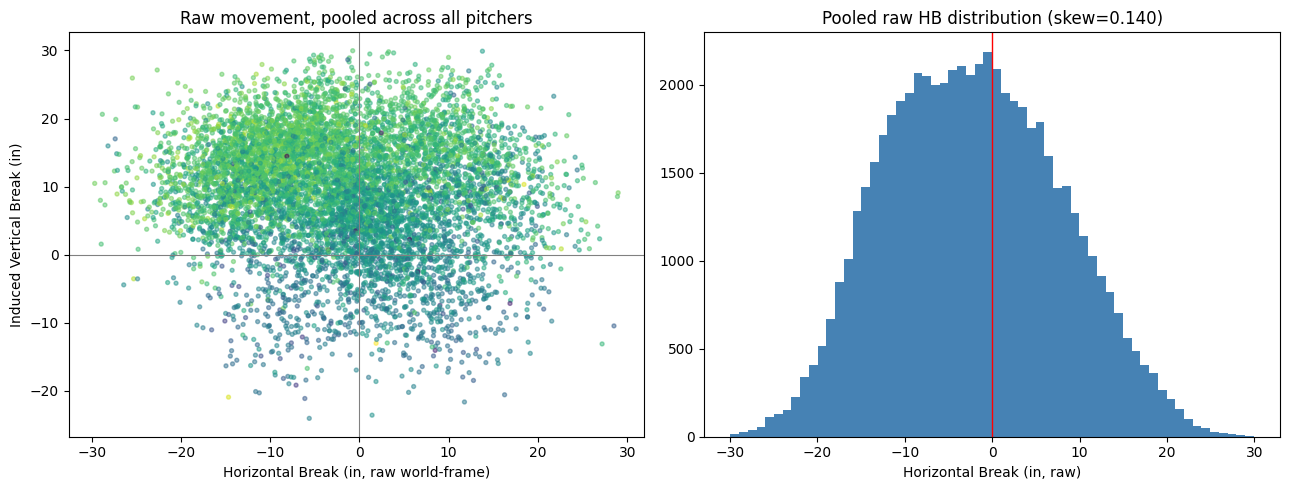

Pooled raw HB skew: 0.1397 (near 0 is consistent with a mixed-handedness population whose arm-side breaks roughly cancel out -- exactly the symmetry that makes raw HB unusable for cross-pitcher clustering without some kind of mirroring.)


In [3]:
sample = df.sample(min(8000, len(df)), random_state=RANDOM_STATE)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(sample["hb_in"], sample["ivb_in"], c=sample["release_speed_mph"],
                cmap="viridis", s=8, alpha=0.5)
axes[0].axvline(0, color="gray", lw=0.8)
axes[0].axhline(0, color="gray", lw=0.8)
axes[0].set_xlabel("Horizontal Break (in, raw world-frame)")
axes[0].set_ylabel("Induced Vertical Break (in)")
axes[0].set_title("Raw movement, pooled across all pitchers")

axes[1].hist(df["hb_in"], bins=60, color="steelblue")
axes[1].axvline(0, color="red", lw=1)
axes[1].set_xlabel("Horizontal Break (in, raw)")
axes[1].set_title(f"Pooled raw HB distribution (skew={skew(df['hb_in']):.3f})")
plt.tight_layout()
plt.show()

print(f"Pooled raw HB skew: {skew(df['hb_in']):.4f} (near 0 is consistent with a mixed-handedness "
      "population whose arm-side breaks roughly cancel out -- exactly the symmetry that makes "
      "raw HB unusable for cross-pitcher clustering without some kind of mirroring.)")


## 3. Data-driven arm-side mirroring

No handedness label exists, so the reference repo's approach (mirror
`HorzBreak` by the known `PitcherThrows` field) isn't directly available.
Instead: a pitcher's hardest pitches (top quartile of their own release
speed -- almost always their fastball/sinker) break to their own arm side
in the overwhelming majority of real pitchers. Use the **sign of the mean
horizontal break among each pitcher's own top-quartile-velocity pitches**
as a data-driven stand-in for "which side is arm-side for this pitcher,"
and mirror every one of their pitches by it.


In [4]:
def reference_sign(group: pd.DataFrame) -> int:
    threshold = group["release_speed_mph"].quantile(0.75)
    fastball_like = group.loc[group["release_speed_mph"] >= threshold, "hb_in"]
    s = np.sign(fastball_like.mean())
    return int(s) if s != 0 else 1

arm_side_sign = df.groupby("pitcher", group_keys=False).apply(
    lambda g: pd.Series(reference_sign(g), index=g.index)
)
df["arm_side_sign"] = arm_side_sign
df["hb_in_mirrored"] = df["hb_in"] * df["arm_side_sign"]

print("arm_side_sign distribution across pitchers (should be a roughly even split, "
      "consistent with a mixed-handed pitcher population):")
print(df.groupby("pitcher")["arm_side_sign"].first().value_counts())


arm_side_sign distribution across pitchers (should be a roughly even split, consistent with a mixed-handed pitcher population):
arm_side_sign
-1    511
 1    228
Name: count, dtype: int64


/var/folders/5p/vrbc0kc57yd4shnbpk0r_0rw0000gn/T/ipykernel_76696/3015126215.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  arm_side_sign = df.groupby("pitcher", group_keys=False).apply(


### 3.1 Validating the mirroring inference (held-out check)

The sign above is *derived from* each pitcher's top-quartile-velocity
subset, so checking it against that same subset would be circular. Instead:
split each pitcher's top-quartile-velocity pitches randomly in half, derive
the reference sign from half A only, and check how often half B's
*individual* pitches land on that same side. If the inferred sign reflects
a real, stable per-pitcher tendency (not noise), this held-out agreement
rate should sit well above 50%.


In [5]:
def heldout_agreement(group: pd.DataFrame, rs: int):
    threshold = group["release_speed_mph"].quantile(0.75)
    fastball_like = group.loc[group["release_speed_mph"] >= threshold].copy()
    if len(fastball_like) < 4:
        return np.nan, len(fastball_like)
    shuffled = fastball_like.sample(frac=1.0, random_state=rs)
    half = len(shuffled) // 2
    a, b = shuffled.iloc[:half], shuffled.iloc[half:]
    sign_a = np.sign(a["hb_in"].mean())
    if sign_a == 0:
        return np.nan, len(fastball_like)
    agreement = (np.sign(b["hb_in"]) == sign_a).mean()
    return agreement, len(fastball_like)

agreement_rows = []
for pitcher, group in df.groupby("pitcher"):
    agreement, n_fb = heldout_agreement(group, RANDOM_STATE)
    agreement_rows.append({"pitcher": pitcher, "agreement": agreement, "n_fastball_like": n_fb,
                            "n_pitches": len(group)})
agreement_df = pd.DataFrame(agreement_rows).dropna(subset=["agreement"])

overall_agreement = agreement_df["agreement"].mean()
high_volume_agreement = agreement_df.loc[agreement_df["n_pitches"] >= 30, "agreement"].mean()

print(f"held-out sign agreement, all eligible pitchers (n={len(agreement_df)}): {overall_agreement:.1%}")
print(f"held-out sign agreement, pitchers with >=30 pitches (n={(agreement_df['n_pitches']>=30).sum()}): "
      f"{high_volume_agreement:.1%}")

grade("Arm-side mirroring", "held-out sign agreement beats chance (50%) for high-volume pitchers",
      high_volume_agreement > 0.65,
      f"{high_volume_agreement:.1%} agreement (n={(agreement_df['n_pitches']>=30).sum()} pitchers)")


held-out sign agreement, all eligible pitchers (n=739): 92.2%
held-out sign agreement, pitchers with >=30 pitches (n=483): 92.4%
PASS [Arm-side mirroring] held-out sign agreement beats chance (50%) for high-volume pitchers: 92.4% agreement (n=483 pitchers)


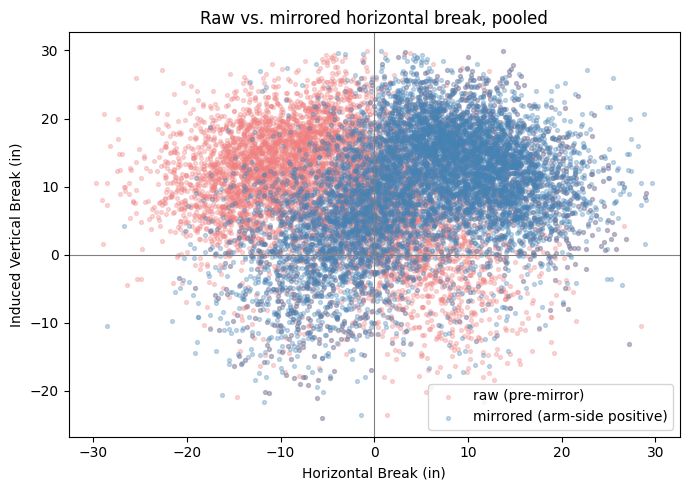

Pooled HB skew: raw=0.140, mirrored=-0.201
PASS [Arm-side mirroring] mirrored HB skew is more pronounced than raw (consistent arm-side convention): raw skew=0.140, mirrored skew=-0.201


In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(sample["hb_in"], sample["ivb_in"], s=8, alpha=0.3, label="raw (pre-mirror)", color="lightcoral")
mirrored_sample = df.loc[sample.index]
ax.scatter(mirrored_sample["hb_in_mirrored"], mirrored_sample["ivb_in"], s=8, alpha=0.3,
           label="mirrored (arm-side positive)", color="steelblue")
ax.axvline(0, color="gray", lw=0.8)
ax.axhline(0, color="gray", lw=0.8)
ax.set_xlabel("Horizontal Break (in)")
ax.set_ylabel("Induced Vertical Break (in)")
ax.set_title("Raw vs. mirrored horizontal break, pooled")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Pooled HB skew: raw={skew(df['hb_in']):.3f}, mirrored={skew(df['hb_in_mirrored']):.3f}")
grade("Arm-side mirroring", "mirrored HB skew is more pronounced than raw (consistent arm-side convention)",
      abs(skew(df["hb_in_mirrored"])) > abs(skew(df["hb_in"])),
      f"raw skew={skew(df['hb_in']):.3f}, mirrored skew={skew(df['hb_in_mirrored']):.3f}")


## 4. Per-pitcher standardization

Z-score velocity, IVB, and mirrored HB *within each pitcher* so a cluster
represents "how unusual is this pitch relative to this pitcher's own
arsenal," not absolute stuff quality (a 78mph "fastball" from a soft
tosser and a 96mph fastball from a flamethrower should both land near the
global "fastball" cluster, since each is unusually fast *for that
pitcher*).


In [7]:
feature_cols = ["release_speed_mph", "ivb_in", "hb_in_mirrored"]
z_cols = ["z_velo", "z_ivb", "z_hb"]

grouped = df.groupby("pitcher")[feature_cols]
means = grouped.transform("mean")
stds = grouped.transform("std").replace(0, np.nan)  # guard against a pitcher with zero variance

for raw_col, z_col in zip(feature_cols, z_cols):
    df[z_col] = (df[raw_col] - means[raw_col]) / stds[raw_col]

n_before = len(df)
df = df.dropna(subset=z_cols).reset_index(drop=True)
print(f"dropped {n_before - len(df)} pitches from zero-variance pitcher groups")
df[z_cols].describe()


dropped 0 pitches from zero-variance pitcher groups


,z_velo,z_ivb,z_hb
count,59321.000,59321.000,59321.000
mean,-0.000,0.000,0.000
std,0.994,0.994,0.994
min,-4.154,-5.582,-4.536
25%,-0.842,-0.667,-0.720
50%,0.313,0.142,0.108
75%,0.812,0.718,0.718
max,3.014,3.916,4.328


## 5. GMM clustering — BIC search over k and covariance type

Mirrors the UCSD reference notebook's `choose_gmm`: grid over the number
of components and covariance structure, pick the combination with the
lowest BIC (penalizes complexity, unlike raw log-likelihood which always
improves with more components).


In [8]:
def choose_gmm(X, k_range, covariance_types):
    best = None
    best_bic = np.inf
    best_gmm = None
    bic_table = []
    for cov in covariance_types:
        for k in k_range:
            gmm = GaussianMixture(n_components=k, covariance_type=cov, reg_covar=1e-4,
                                   n_init=5, random_state=RANDOM_STATE)
            gmm.fit(X)
            bic = gmm.bic(X)
            bic_table.append({"k": k, "covariance_type": cov, "bic": bic})
            if bic < best_bic:
                best_bic = bic
                best = (k, cov, bic)
                best_gmm = gmm
    return best, best_gmm, pd.DataFrame(bic_table)

X = df[z_cols].to_numpy()
K_RANGE = range(3, 13)
COV_TYPES = ("full", "diag")

best, gmm, bic_table = choose_gmm(X, K_RANGE, COV_TYPES)
best_k, best_cov, best_bic = best
print(f"chosen model: k={best_k}, covariance_type={best_cov}, BIC={best_bic:.1f}")


chosen model: k=9, covariance_type=full, BIC=419052.6


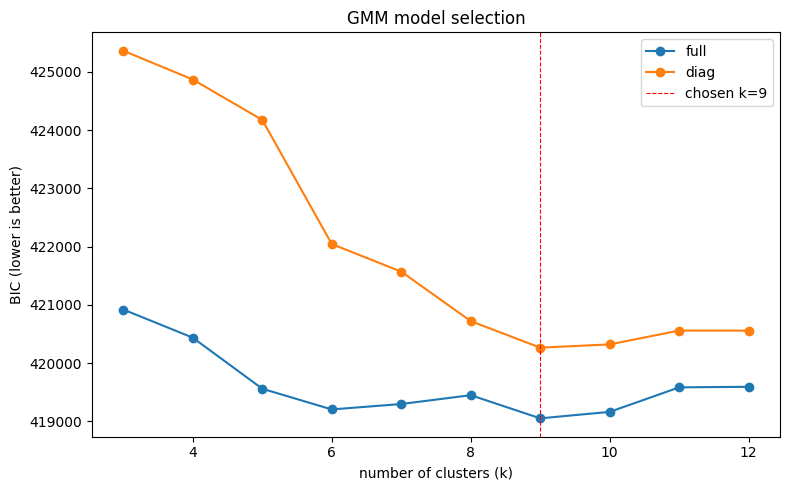

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
for cov in COV_TYPES:
    subset = bic_table[bic_table["covariance_type"] == cov]
    ax.plot(subset["k"], subset["bic"], marker="o", label=cov)
ax.axvline(best_k, color="red", linestyle="--", lw=0.8, label=f"chosen k={best_k}")
ax.set_xlabel("number of clusters (k)")
ax.set_ylabel("BIC (lower is better)")
ax.set_title("GMM model selection")
ax.legend()
plt.tight_layout()
plt.show()


In [10]:
proba = gmm.predict_proba(X)
df["cluster"] = proba.argmax(axis=1)
for c in range(best_k):
    df[f"cluster_{c}_prob"] = proba[:, c]

cluster_sizes = df["cluster"].value_counts().sort_index()
print("cluster sizes:")
print(cluster_sizes)
print()
print("cluster share:")
print((cluster_sizes / len(df)).round(3))


cluster sizes:
cluster
0     2433
1     3927
2     9086
3     1366
4     6096
5     4235
6     5886
7     7292
8    19000
Name: count, dtype: int64

cluster share:
cluster
0   0.041
1   0.066
2   0.153
3   0.023
4   0.103
5   0.071
6   0.099
7   0.123
8   0.320
Name: count, dtype: float64


## 6. Model validation and scoring

Concrete numeric checks, same `grade()` PASS/FAIL convention as
`process_assessment.ipynb`. Silhouette is computed on a subsample (it's
O(n^2) in memory) for tractability; the other checks run on the full
clustered dataset.


In [11]:
sil_sample_idx = df.sample(min(8000, len(df)), random_state=RANDOM_STATE).index
sil_score = silhouette_score(df.loc[sil_sample_idx, z_cols], df.loc[sil_sample_idx, "cluster"])
db_score = davies_bouldin_score(df[z_cols], df["cluster"])

print(f"silhouette score (n={len(sil_sample_idx)} subsample): {sil_score:.3f}")
print(f"Davies-Bouldin index (full data, lower is better): {db_score:.3f}")

grade("Cluster quality", "silhouette score indicates real (non-overlapping-noise) cluster structure",
      sil_score > 0.15, f"silhouette={sil_score:.3f}")

min_share = (cluster_sizes / len(df)).min()
grade("Cluster balance", "no degenerate cluster captures <1% of pitches",
      min_share >= 0.01, f"smallest cluster share={min_share:.1%}")


silhouette score (n=8000 subsample): 0.200
Davies-Bouldin index (full data, lower is better): 1.613
PASS [Cluster quality] silhouette score indicates real (non-overlapping-noise) cluster structure: silhouette=0.200
PASS [Cluster balance] no degenerate cluster captures <1% of pitches: smallest cluster share=2.3%


### 6.1 Bootstrap stability

Refit the chosen GMM on several random 70% subsamples and compare cluster
assignments (on the overlapping pitches, via Adjusted Rand Index against
the full-data labels) -- a model whose clusters are real structure, not
noise, should be reasonably stable across resamples.


In [12]:
ari_scores = []
for i in range(5):
    sub_idx = df.sample(frac=0.7, random_state=RANDOM_STATE + i).index
    X_sub = df.loc[sub_idx, z_cols].to_numpy()
    gmm_sub = GaussianMixture(n_components=best_k, covariance_type=best_cov, reg_covar=1e-4,
                               n_init=3, random_state=RANDOM_STATE + i)
    sub_labels = gmm_sub.fit_predict(X_sub)
    ari = adjusted_rand_score(df.loc[sub_idx, "cluster"], sub_labels)
    ari_scores.append(ari)

mean_ari = float(np.mean(ari_scores))
print(f"bootstrap ARI scores (5 resamples): {[round(a, 3) for a in ari_scores]}")
print(f"mean ARI: {mean_ari:.3f}")

grade("Cluster stability", "mean bootstrap ARI indicates reasonably stable cluster structure",
      mean_ari > 0.4, f"mean ARI={mean_ari:.3f} across 5 70% resamples")


bootstrap ARI scores (5 resamples): [0.504, 0.877, 0.473, 0.847, 0.633]
mean ARI: 0.667
PASS [Cluster stability] mean bootstrap ARI indicates reasonably stable cluster structure: mean ARI=0.667 across 5 70% resamples


### 6.2 Physical plausibility — cluster centroid table

Sanity-check the clusters against real pitch-physics intuition: the
highest relative-velocity cluster should show the least relative drop
(closest to a fastball), and clusters with the most relative drop should
show below-average relative velocity (consistent with how real breaking
balls trade velocity for movement).


In [13]:
centroid_table = (
    df.groupby("cluster")
    .agg(
        n_pitches=("cluster", "size"),
        mean_release_speed_mph=("release_speed_mph", "mean"),
        mean_ivb_in=("ivb_in", "mean"),
        mean_hb_in_mirrored=("hb_in_mirrored", "mean"),
        z_velo=("z_velo", "mean"),
        z_ivb=("z_ivb", "mean"),
        z_hb=("z_hb", "mean"),
    )
    .reset_index()
    .sort_values("z_velo", ascending=False)
)
centroid_table


,cluster,n_pitches,mean_release_speed_mph,mean_ivb_in,mean_hb_in_mirrored,z_velo,z_ivb,z_hb
4,4,6096,92.035,15.048,14.646,0.948,0.759,1.254
8,8,19000,91.641,15.690,7.457,0.789,0.738,0.258
1,1,3927,90.714,5.562,12.065,0.685,-0.452,0.706
6,6,5886,88.467,10.645,0.465,0.249,0.131,-0.624
3,3,1366,85.053,-0.132,7.227,-0.443,-1.382,0.311
7,7,7292,83.155,8.791,11.849,-0.742,-0.139,0.803
2,2,9086,82.185,1.462,-3.830,-0.966,-0.909,-0.992
0,0,2433,80.535,11.761,-3.389,-1.171,0.512,-0.981
5,5,4235,78.368,-5.195,-7.053,-1.721,-1.827,-1.539


In [14]:
fastest_cluster = centroid_table.iloc[0]
slowest_cluster = centroid_table.iloc[-1]
grade("Physical plausibility", "highest relative-velocity cluster has above-average relative IVB "
      "(fastballs drop less than a pitcher's average pitch)",
      fastest_cluster["z_ivb"] > 0,
      f"fastest cluster (z_velo={fastest_cluster['z_velo']:.2f}) has z_ivb={fastest_cluster['z_ivb']:.2f}")

grade("Physical plausibility", "lowest relative-velocity cluster has below-average relative IVB "
      "(consistent with curveball-like pitches trading velocity for drop)",
      slowest_cluster["z_ivb"] < 0,
      f"slowest cluster (z_velo={slowest_cluster['z_velo']:.2f}) has z_ivb={slowest_cluster['z_ivb']:.2f}")


PASS [Physical plausibility] highest relative-velocity cluster has above-average relative IVB (fastballs drop less than a pitcher's average pitch): fastest cluster (z_velo=0.95) has z_ivb=0.76
PASS [Physical plausibility] lowest relative-velocity cluster has below-average relative IVB (consistent with curveball-like pitches trading velocity for drop): slowest cluster (z_velo=-1.72) has z_ivb=-1.83


## 7. Heuristic pitch-type labels

**This section is explicitly a heuristic, not a validated classifier.**
There is no ground-truth pitch-type label anywhere in this dataset to
check it against (unlike the UCSD reference pipeline, which had a
real-MLB-Statcast-trained supervised model to translate unsupervised
clusters into canonical names). Each cluster is assigned the canonical
archetype whose *typical relative profile* (in the same per-pitcher
z-score space) is closest, using approximate real-world tendencies
(fastballs: high relative velo, low relative break; sliders: below-average
velo, glove-side break, moderate drop; curveballs: lowest relative velo,
biggest relative drop; etc.) as reference points. Treat the resulting
names as a readable convenience label for the app, not ground truth.


In [15]:
# Approximate archetype reference points in (z_velo, z_ivb, z_hb) space, where
# z_hb is in the "arm-side positive" mirrored convention from Sec. 3.
# These are intentionally coarse -- relative position to a pitcher's OWN
# average pitch, not absolute MLB averages (which we have no way to map
# this dataset's pitcher population onto without real spin/handedness data).
ARCHETYPES = {
    "Fastball":   (1.1,  0.6,  0.3),
    "Sinker":     (0.9, -0.4,  0.9),
    "Cutter":     (0.5,  0.1, -0.6),
    "Changeup":   (-0.6, 0.4,  0.6),
    "Slider":     (-0.3, -0.6, -0.9),
    "Curveball":  (-1.0, -1.3, -0.2),
}

def assign_archetype(row):
    point = np.array([row["z_velo"], row["z_ivb"], row["z_hb"]])
    dists = {name: np.linalg.norm(point - np.array(ref)) for name, ref in ARCHETYPES.items()}
    return min(dists, key=dists.get)

centroid_table["heuristic_label"] = centroid_table.apply(assign_archetype, axis=1)
label_map = dict(zip(centroid_table["cluster"], centroid_table["heuristic_label"]))
df["pitch_type_label"] = df["cluster"].map(label_map)

print("cluster -> heuristic label assignment:")
print(centroid_table[["cluster", "n_pitches", "z_velo", "z_ivb", "z_hb", "heuristic_label"]])
print()
print("label distribution across all pitches:")
print(df["pitch_type_label"].value_counts())

n_unique_labels = centroid_table["heuristic_label"].nunique()
grade("Heuristic labeling", "distinct clusters map to more than one label (not collapsed to a single archetype)",
      n_unique_labels > 1, f"{n_unique_labels} distinct labels across {best_k} clusters")


cluster -> heuristic label assignment:
   cluster  n_pitches  z_velo  z_ivb   z_hb heuristic_label
4        4       6096   0.948  0.759  1.254        Fastball
8        8      19000   0.789  0.738  0.258        Fastball
1        1       3927   0.685 -0.452  0.706          Sinker
6        6       5886   0.249  0.131 -0.624          Cutter
3        3       1366  -0.443 -1.382  0.311       Curveball
7        7       7292  -0.742 -0.139  0.803        Changeup
2        2       9086  -0.966 -0.909 -0.992          Slider
0        0       2433  -1.171  0.512 -0.981          Slider
5        5       4235  -1.721 -1.827 -1.539       Curveball

label distribution across all pitches:
pitch_type_label
Fastball     25096
Slider       11519
Changeup      7292
Cutter        5886
Curveball     5601
Sinker        3927
Name: count, dtype: int64
PASS [Heuristic labeling] distinct clusters map to more than one label (not collapsed to a single archetype): 6 distinct labels across 9 clusters


## 8. Per-pitcher visualization

A handful of example pitchers, plotted in their own raw IVB/HB space
(mirrored convention), colored by assigned cluster -- the same diagnostic
plot the UCSD reference notebook uses (`plot_clusters`) to manually sanity
check that a pitcher's distinct pitch types are actually visually
separable, not an artifact of the global model.


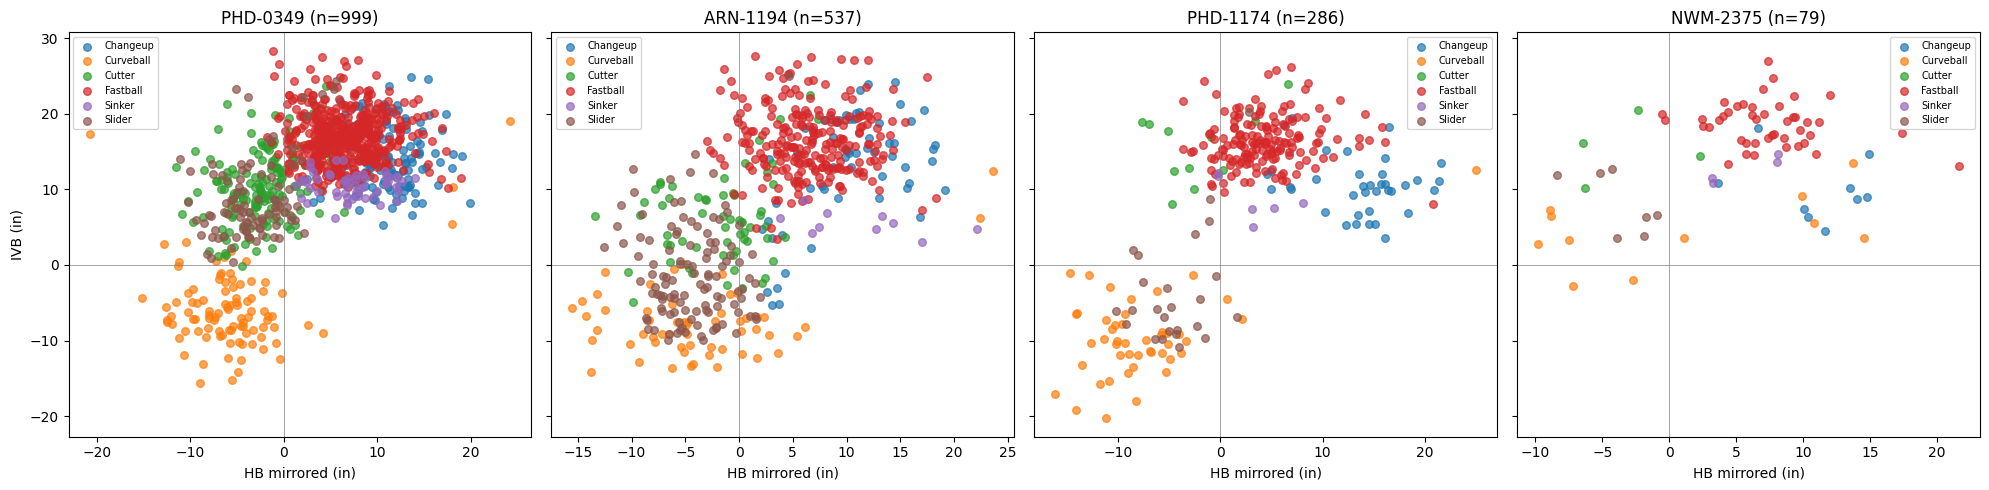

In [16]:
example_pitchers = (
    df.groupby("pitcher").size().sort_values(ascending=False).index[[0, 10, 50, 150]]
)

fig, axes = plt.subplots(1, len(example_pitchers), figsize=(5 * len(example_pitchers), 5), sharey=True)
for ax, pitcher in zip(axes, example_pitchers):
    sub = df[df["pitcher"] == pitcher]
    for label, group in sub.groupby("pitch_type_label"):
        ax.scatter(group["hb_in_mirrored"], group["ivb_in"], label=label, s=30, alpha=0.7)
    ax.axvline(0, color="gray", lw=0.5)
    ax.axhline(0, color="gray", lw=0.5)
    ax.set_xlabel("HB mirrored (in)")
    ax.set_title(f"{pitcher} (n={len(sub)})")
    ax.legend(fontsize=7)
axes[0].set_ylabel("IVB (in)")
plt.tight_layout()
plt.show()


## 9. Export

Writes `Data/derived/pitch_type.csv`: one row per pitch, keyed by
`game_string`/`play_per_game` (joins cleanly onto `pitch_movement.csv`,
`pitch_zone.csv`, and `play_state.csv`), with the hard cluster label, the
heuristic pitch-type name, and per-cluster soft probabilities for the app
to use (e.g. surfacing confidence, or excluding ambiguous pitches from
"this pitcher's signature pitch" style framing).


In [17]:
prob_cols = [f"cluster_{c}_prob" for c in range(best_k)]
export_cols = ["game_string", "play_per_game", "pitcher", "release_speed_mph", "ivb_in",
               "hb_in", "hb_in_mirrored", "cluster", "pitch_type_label"] + prob_cols

pitch_type = df[export_cols].copy()
pitch_type.to_csv(OUT_PATH, index=False)

print(f"wrote {OUT_PATH}")
print(f"rows: {len(pitch_type)}, pitchers: {pitch_type['pitcher'].nunique()}")
print(pitch_type["pitch_type_label"].value_counts(normalize=True).round(3))


wrote Data/derived/pitch_type.csv
rows: 59321, pitchers: 739
pitch_type_label
Fastball    0.423
Slider      0.194
Changeup    0.123
Cutter      0.099
Curveball   0.094
Sinker      0.066
Name: proportion, dtype: float64


## 10. Summary

Validation checks run in this notebook:


In [18]:
summary = pd.DataFrame(results)
print(f"{summary['passed'].sum()}/{len(summary)} checks passed")
summary


8/8 checks passed


,section,check,passed,detail
0,Arm-side mirroring,held-out sign agreement beats chance (50%) for...,True,92.4% agreement (n=483 pitchers)
1,Arm-side mirroring,mirrored HB skew is more pronounced than raw (...,True,"raw skew=0.140, mirrored skew=-0.201"
2,Cluster quality,silhouette score indicates real (non-overlappi...,True,silhouette=0.200
3,Cluster balance,no degenerate cluster captures <1% of pitches,True,smallest cluster share=2.3%
4,Cluster stability,mean bootstrap ARI indicates reasonably stable...,True,mean ARI=0.667 across 5 70% resamples
5,Physical plausibility,highest relative-velocity cluster has above-av...,True,fastest cluster (z_velo=0.95) has z_ivb=0.76
6,Physical plausibility,lowest relative-velocity cluster has below-ave...,True,slowest cluster (z_velo=-1.72) has z_ivb=-1.83
7,Heuristic labeling,distinct clusters map to more than one label (...,True,6 distinct labels across 9 clusters


**Known limitations, to revisit before this feeds the app:**

- The arm-side mirroring sign (Sec. 3) is inferred, not measured. The
  held-out validation (Sec. 3.1) confirms it's better than chance for
  higher-volume pitchers, but low-volume pitchers' signs are noisier --
  worth a minimum-volume gate before letting a pitcher be a selectable app
  opponent, separate from the `MIN_PITCHES_PER_PITCHER` clustering
  threshold above.
- Heuristic pitch-type names (Sec. 7) are a best-effort convenience
  mapping with no ground truth to check against -- expect some
  misclassification, especially between adjacent archetypes (e.g.
  Cutter/Slider, Sinker/Changeup) that differ mainly in degree rather than
  kind.
- `MIN_PITCHES_PER_PITCHER = 15` and the BIC-selected `k` were not tuned
  against any external benchmark (none exists for this dataset) --
  re-run Sec. 5/6 if `derive_pitch_movement.py`'s output changes
  materially.
